# 02 - Auditoria temporal e base mestra

**Objetivo:** reconstruir a linha temporal de 10 em 10 minutos, revelar lacunas e construir uma base comum.

### Por que isso e importante?
Um timestamp que nao existe no CSV e diferente de um valor `NaN` que existe numa linha. Reindexar para uma grade temporal explicita revela ambos.

### Saidas
- `station_audit.csv/html`
- graficos de cobertura;
- `master_all_sensors.parquet`
- `master_base.parquet`

In [11]:
from pathlib import Path
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------------------------------------------------------
# Localiza a raiz do projeto e o dataset de forma robusta.
# Funciona se o notebook estiver em Field-Project/notebooks.
# ------------------------------------------------------------------
CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

RAW_PARENT = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"

OUTPUTS = ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
PREDICTIONS = OUTPUTS / "predictions"

for p in [INTERIM, PROCESSED, MODELS, FIGURES, TABLES, PREDICTIONS]:
    p.mkdir(parents=True, exist_ok=True)

def find_dataset_root(raw_parent: Path) -> Path:
    """Procura uma pasta que contenha Data/SHP e Data/Telemetric_Time_Series."""
    candidates = [raw_parent] + [p for p in raw_parent.rglob("*") if p.is_dir()]
    for p in candidates:
        data = p / "Data"
        if (data / "SHP").exists() and (data / "Telemetric_Time_Series").exists():
            return p
    raise FileNotFoundError(
        "Nao encontrei o dataset. Extraia o .rar dentro de data/raw/ "
        "mantendo a pasta Data/ com SHP/, Radar/ e Telemetric_Time_Series/."
    )

RAW = find_dataset_root(RAW_PARENT)
DATA = RAW / "Data"
SHP = DATA / "SHP"
TELE = DATA / "Telemetric_Time_Series"
RADAR = DATA / "Radar"

print("ROOT:", ROOT)
print("Dataset:", RAW)

ROOT: C:\Users\osmar\Área de Trabalho\Field-Project
Dataset: C:\Users\osmar\Área de Trabalho\Field-Project\data\raw\TTI-HydroMet_Dataset_version2


In [12]:
def save_table(df, stem, preview_rows=15, sort_by=None, ascending=True):
    """
    Salva a tabela completa em CSV e HTML e mostra apenas uma amostra no notebook.
    Isso evita outputs gigantes e facilita abrir a tabela fora do Jupyter.
    """
    z = df.copy()
    if sort_by is not None and sort_by in z.columns:
        z = z.sort_values(sort_by, ascending=ascending)

    csv_path = TABLES / f"{stem}.csv"
    html_path = TABLES / f"{stem}.html"

    z.to_csv(csv_path, index=False)
    z.to_html(html_path, index=False)

    display(Markdown(
        f"**Tabela completa salva em:**  \n"
        f"- `{csv_path.relative_to(ROOT)}`  \n"
        f"- `{html_path.relative_to(ROOT)}`  \n"
        f"Mostrando apenas as primeiras {min(preview_rows, len(z))} linhas:"
    ))
    display(z.head(preview_rows))
    return z

def save_figure(fig, stem, dpi=220):
    """Salva uma figura em PNG e a mantem visivel no notebook."""
    path = FIGURES / f"{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    display(Markdown(f"**Figura salva em:** `{path.relative_to(ROOT)}`"))
    return path

In [13]:
GAUGE_IDS = [143, 275, 279, 280, 283, 413, 511, 563, 629, 1000350, 1000370, 1000390, 1000400, 1000410, 1000420, 1000430, 1000490, 1000500, 1000510, 1000550, 1000837, 1000839, 1000867]

In [14]:
START = pd.Timestamp("2015-04-01 00:00:00")
END = pd.Timestamp("2025-03-29 23:50:00")
MASTER_TIME = pd.date_range(START, END, freq="10min", name="time")

print("Timestamps esperados:", len(MASTER_TIME))
assert len(MASTER_TIME) == 525_744

Timestamps esperados: 525744


In [15]:
def read_station(station_id):
    path = TELE / f"P_{station_id}_INST.csv"
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path, low_memory=False)
    if "DATA" not in df.columns:
        raise ValueError(f"{path.name} nao possui coluna DATA.")

    df["DATA"] = pd.to_datetime(df["DATA"], format="mixed", errors="coerce")
    invalid_dates = int(df["DATA"].isna().sum())
    df = df.dropna(subset=["DATA"])
    df = df[(df["DATA"] >= START) & (df["DATA"] <= END)].copy()

    value_cols = [c for c in ["PLUmm", "FLUm", "Qm3s"] if c in df.columns]
    for c in value_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    duplicate_rows = int(df["DATA"].duplicated(keep=False).sum())
    duplicate_times = int(df["DATA"].duplicated().sum())

    conflicts = 0
    if duplicate_rows:
        dup = df[df["DATA"].duplicated(keep=False)]
        for _, g in dup.groupby("DATA"):
            for c in value_cols:
                if g[c].dropna().nunique() > 1:
                    conflicts += 1

    out = df.groupby("DATA")[value_cols].mean().reindex(MASTER_TIME)

    return out, {
        "station": station_id,
        "invalid_dates": invalid_dates,
        "duplicate_rows": duplicate_rows,
        "duplicate_times": duplicate_times,
        "conflicts": conflicts,
    }

def station_id_from_path(path):
    m = re.search(r"P_(\d+)_INST", path.stem)
    return int(m.group(1))

ALL_STATION_IDS = [station_id_from_path(p) for p in sorted(TELE.glob("P_*_INST.csv"))]
print("Estacoes:", len(ALL_STATION_IDS))

Estacoes: 37


In [16]:
audit_rows = []

for sid in ALL_STATION_IDS:
    s, diag = read_station(sid)
    row = dict(diag)

    for col in ["PLUmm", "FLUm", "Qm3s"]:
        if col in s.columns:
            row[f"{col}_coverage"] = float(s[col].notna().mean())
            row[f"{col}_missing"] = int(s[col].isna().sum())
            row[f"{col}_min"] = s[col].min()
            row[f"{col}_max"] = s[col].max()
        else:
            row[f"{col}_coverage"] = np.nan
            row[f"{col}_missing"] = np.nan
            row[f"{col}_min"] = np.nan
            row[f"{col}_max"] = np.nan

    audit_rows.append(row)

audit = pd.DataFrame(audit_rows).sort_values("station").reset_index(drop=True)
save_table(audit, "station_audit", preview_rows=15)

**Tabela completa salva em:**  
- `outputs\tables\station_audit.csv`  
- `outputs\tables\station_audit.html`  
Mostrando apenas as primeiras 15 linhas:

,station,invalid_dates,duplicate_rows,duplicate_times,conflicts,PLUmm_coverage,PLUmm_missing,PLUmm_min,PLUmm_max,FLUm_coverage,FLUm_missing,FLUm_min,FLUm_max,Qm3s_coverage,Qm3s_missing,Qm3s_min,Qm3s_max
0,143,0,22,11,1,0.981246,9860.0,0.0,23.8,0.979673,10687.0,733.139,738.582,NaN,NaN,NaN,NaN
1,275,0,22,11,1,0.998182,956.0,0.0,43.6,0.998203,945.0,727.397,732.725,0.998203,945.0,0.483469,127.906806
2,279,0,22,11,1,0.935413,33956.0,0.0,25.0,0.930847,36357.0,736.907,747.114,0.000000,525744.0,NaN,NaN
3,280,0,22,11,0,0.997413,1360.0,0.0,23.8,0.969864,15844.0,734.174,738.905,0.000000,525744.0,NaN,NaN
4,283,0,24,12,1,0.996329,1930.0,0.0,22.0,0.972574,14419.0,721.098,733.473,0.972572,14420.0,7.728000,928.144000
5,413,0,24,12,1,0.976901,12144.0,0.0,21.6,0.971539,14963.0,714.402,726.528,NaN,NaN,NaN,NaN
6,511,0,22,11,1,0.999654,182.0,0.0,18.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,563,0,22,11,1,0.998033,1034.0,0.0,22.2,0.996255,1969.0,739.475,749.900,NaN,NaN,NaN,NaN
8,629,0,24,12,1,0.998353,866.0,0.0,22.6,0.995317,2462.0,724.354,733.467,NaN,NaN,NaN,NaN
9,730,0,6,3,3,NaN,NaN,NaN,NaN,0.465942,280778.0,0.000,735.983,NaN,NaN,NaN,NaN


,station,invalid_dates,duplicate_rows,duplicate_times,conflicts,PLUmm_coverage,PLUmm_missing,PLUmm_min,PLUmm_max,FLUm_coverage,FLUm_missing,FLUm_min,FLUm_max,Qm3s_coverage,Qm3s_missing,Qm3s_min,Qm3s_max
0,143,0,22,11,1,0.981246,9860.0,0.0,23.80,0.979673,10687.0,733.139,738.582,NaN,NaN,NaN,NaN
1,275,0,22,11,1,0.998182,956.0,0.0,43.60,0.998203,945.0,727.397,732.725,0.998203,945.0,0.483469,127.906806
2,279,0,22,11,1,0.935413,33956.0,0.0,25.00,0.930847,36357.0,736.907,747.114,0.000000,525744.0,NaN,NaN
3,280,0,22,11,0,0.997413,1360.0,0.0,23.80,0.969864,15844.0,734.174,738.905,0.000000,525744.0,NaN,NaN
4,283,0,24,12,1,0.996329,1930.0,0.0,22.00,0.972574,14419.0,721.098,733.473,0.972572,14420.0,7.728000,928.144000
5,413,0,24,12,1,0.976901,12144.0,0.0,21.60,0.971539,14963.0,714.402,726.528,NaN,NaN,NaN,NaN
6,511,0,22,11,1,0.999654,182.0,0.0,18.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,563,0,22,11,1,0.998033,1034.0,0.0,22.20,0.996255,1969.0,739.475,749.900,NaN,NaN,NaN,NaN
8,629,0,24,12,1,0.998353,866.0,0.0,22.60,0.995317,2462.0,724.354,733.467,NaN,NaN,NaN,NaN
9,730,0,6,3,3,NaN,NaN,NaN,NaN,0.465942,280778.0,0.000,735.983,NaN,NaN,NaN,NaN


**Tabela completa salva em:**  
- `outputs\tables\level_sensor_coverage.csv`  
- `outputs\tables\level_sensor_coverage.html`  
Mostrando apenas as primeiras 18 linhas:

,station,FLUm_coverage
1,275,0.998203
7,563,0.996255
8,629,0.995317
16,1000370,0.991791
33,1000839,0.989953
21,1000430,0.989141
30,1000610,0.987602
24,1000510,0.985033
0,143,0.979673
17,1000390,0.974716


**Figura salva em:** `outputs\figures\cobertura_nivel_estacoes.png`

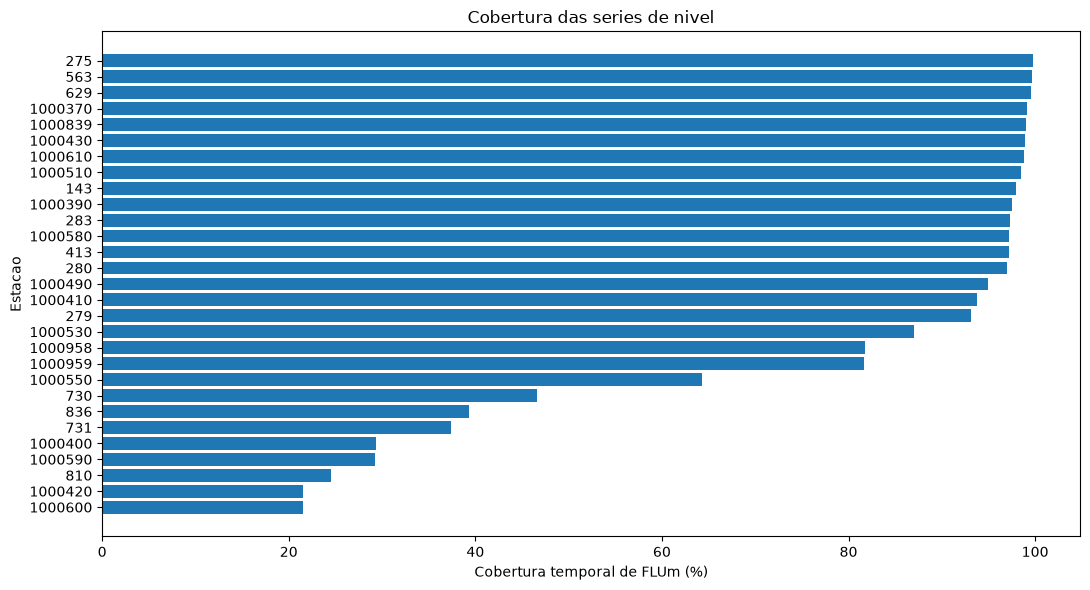

In [17]:
# Mostra apenas os melhores sensores de nivel e salva a lista completa.
level_quality = audit[["station", "FLUm_coverage"]].dropna().sort_values(
    "FLUm_coverage", ascending=False
)
save_table(level_quality, "level_sensor_coverage", preview_rows=18)

fig, ax = plt.subplots(figsize=(11, 6))
plot_df = level_quality.sort_values("FLUm_coverage")
ax.barh(plot_df["station"].astype(str), 100 * plot_df["FLUm_coverage"])
ax.set_xlabel("Cobertura temporal de FLUm (%)")
ax.set_ylabel("Estacao")
ax.set_title("Cobertura das series de nivel")
plt.tight_layout()
save_figure(fig, "cobertura_nivel_estacoes")
plt.show()

In [18]:
master_all = pd.DataFrame(index=MASTER_TIME)

for sid in ALL_STATION_IDS:
    s, _ = read_station(sid)
    if "PLUmm" in s.columns:
        master_all[f"rain_{sid}"] = s["PLUmm"].astype("float32")
    if "FLUm" in s.columns:
        master_all[f"stage_{sid}"] = s["FLUm"].astype("float32")
    if "Qm3s" in s.columns:
        master_all[f"flow_{sid}"] = s["Qm3s"].astype("float32")

master_all.to_parquet(PROCESSED / "master_all_sensors.parquet")
print("Base completa:", master_all.shape)
print("Salva em:", (PROCESSED / "master_all_sensors.parquet").relative_to(ROOT))

Base completa: (525744, 61)
Salva em: data\processed\master_all_sensors.parquet


In [19]:
master = pd.DataFrame(index=MASTER_TIME)

for sid in GAUGE_IDS:
    s, _ = read_station(sid)
    if "PLUmm" in s.columns:
        master[f"rain_{sid}"] = s["PLUmm"].astype("float32")

for sid in [1000490, 143, 283, 413]:
    s, _ = read_station(sid)
    if "FLUm" not in s.columns:
        raise ValueError(f"Estacao {sid} sem FLUm.")
    master[f"stage_{sid}"] = s["FLUm"].astype("float32")

assert master.shape == (525_744, 27), master.shape
master.to_parquet(PROCESSED / "master_base.parquet")

compact = pd.DataFrame({
    "variavel": master.columns,
    "cobertura_pct": [100 * master[c].notna().mean() for c in master.columns],
    "faltantes": [int(master[c].isna().sum()) for c in master.columns],
})
save_table(compact, "master_base_coverage", preview_rows=27)

**Tabela completa salva em:**  
- `outputs\tables\master_base_coverage.csv`  
- `outputs\tables\master_base_coverage.html`  
Mostrando apenas as primeiras 27 linhas:

,variavel,cobertura_pct,faltantes
0,rain_143,98.124563,9860
1,rain_275,99.818162,956
2,rain_279,93.541343,33956
3,rain_280,99.741319,1360
4,rain_283,99.632901,1930
5,rain_413,97.690131,12144
6,rain_511,99.965382,182
7,rain_563,99.803326,1034
8,rain_629,99.835281,866
9,rain_1000350,98.015194,10435


,variavel,cobertura_pct,faltantes
0,rain_143,98.124563,9860
1,rain_275,99.818162,956
2,rain_279,93.541343,33956
3,rain_280,99.741319,1360
4,rain_283,99.632901,1930
5,rain_413,97.690131,12144
6,rain_511,99.965382,182
7,rain_563,99.803326,1034
8,rain_629,99.835281,866
9,rain_1000350,98.015194,10435


**Figura salva em:** `outputs\figures\stage_413_full.png`

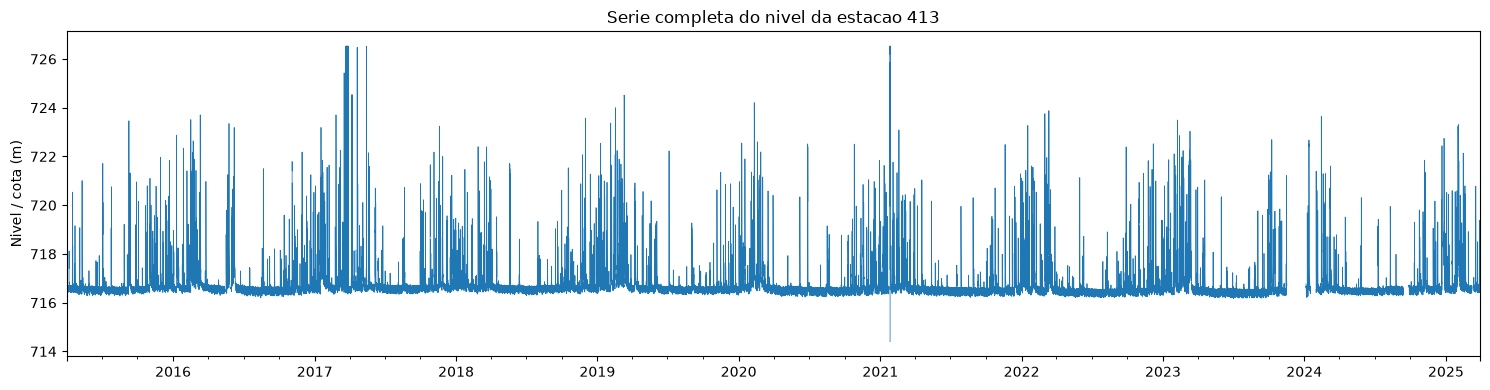

In [20]:
fig, ax = plt.subplots(figsize=(15, 4))
master["stage_413"].plot(ax=ax, linewidth=0.55)
ax.set_title("Serie completa do nivel da estacao 413")
ax.set_ylabel("Nivel / cota (m)")
ax.set_xlabel("")
plt.tight_layout()
save_figure(fig, "stage_413_full")
plt.show()